# Problem 4 - Regression over Autoregressive Forecast

## Agenda
- Problem Description
- Problem Implementation
- Alternative Problems
- Wrap-Up

## Problem Description
- <b>Consider a set of stochastic variables <i>X</i> and an electrical quantity <i>y</i> dependent on such variables for which timeseries data are available (both for the variables and the quantity) and discover an accurate predictor for <i>y</i> based on the forecasts of <i>X</i>.<b>

    _______________________________________________________________________________________________________________________

Considered "Kite" 5 Bus Network
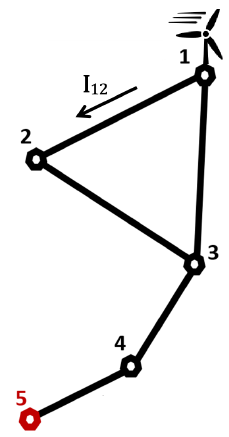

- <b>Implementation<b>
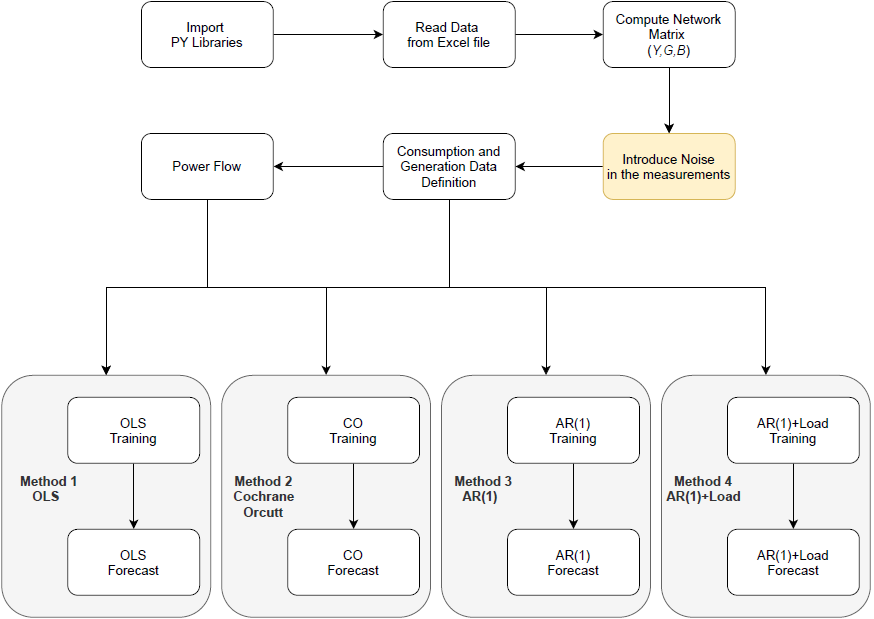

<b>Import Python Libraries

In [267]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<b>Parameters

In [268]:
networkFactor = 100    # To change the characteristics of the network (Y)
cosPhi=0.95            # Value of teta
time=24                # Training Period  
timeForecast=12        # Test Period

<b>Import data (From Excel file)

In [269]:
Info = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Info', header=None))
# Information about the slack bus
SlackBus=Info[0,1]
print ("Slack Bus: ", SlackBus,"\n")

# Network Information
Net_Info = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Y_Data'))
print ("Lines information (Admitances)\n", Net_Info, "\n")

#Power Information (Train)
Power_Info = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Load(t,Bus)'))
Power_Info = np.delete(Power_Info,[0],1)
print ("Power consumption information (time, Bus)\n", Power_Info, "\n")

#Power Information (Test)
Power_Test = np.array(pd.read_excel (r'DASG_Prob2_new.xlsx', sheet_name='Test_Load(t,Bus)'))
Power_Test = np.delete(Power_Test,[0],1)
print ("Power consumption information (time, Bus)\n", Power_Test, "\n")

P=np.dot(-Power_Info,np.exp(complex(0,1)*np.arccos(cosPhi)))
I=np.conj(P[2,:])


P=np.dot(-Power_Info,np.exp(complex(0,1)*np.arccos(cosPhi)))
print(P)
I=np.conj(P[2,:])



Slack Bus:  5 

Lines information (Admitances)
 [[1 2 '0,01-0,1i']
 [1 3 '0,02-0,2i']
 [2 3 '0,03-0,2i']
 [3 4 '0,03-0,2i']
 [4 5 '0,02-0,2i']] 

Power consumption information (time, Bus)
 [[0.332 0.064 0.084 0.12 ]
 [0.236 0.164 0.276 0.064]
 [0.224 0.708 1.572 0.072]
 [0.36  3.44  1.188 0.18 ]
 [1.332 2.176 0.484 1.464]
 [1.516 3.02  0.316 0.624]
 [0.92  0.916 0.404 2.772]
 [0.752 0.64  0.396 1.464]
 [1.828 0.684 0.576 0.576]
 [3.568 0.564 0.828 0.428]
 [0.78  0.356 0.728 0.348]
 [0.856 0.22  0.308 0.12 ]
 [0.684 0.528 0.256 0.44 ]] 

Power consumption information (time, Bus)
 [[0.18  0.06  0.188 0.132]
 [0.1   0.06  0.992 0.132]
 [0.388 0.1   1.576 0.132]
 [0.28  0.196 0.08  1.94 ]
 [0.5   0.184 0.064 0.572]
 [1.16  0.108 0.064 0.188]
 [1.036 0.06  0.068 0.08 ]
 [1.036 0.064 0.112 0.064]
 [1.768 0.064 0.2   0.068]
 [0.804 0.092 0.184 0.064]
 [0.824 0.196 0.088 0.096]
 [0.52  0.188 0.064 0.196]
 [0.184 0.104 0.068 0.192]] 

[[-0.3154-0.10366697j -0.0608-0.01998399j -0.0798-0.02622899

<b>Admittance Matrix(<i>Y</i>); Conductance Matrix(<i>G</i>); Susceptance Matrix(<i>B</i>)

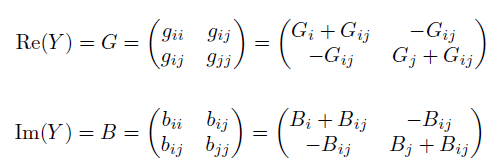

In [270]:
# Determine the number of Bus
nBus=max(np.max(Net_Info[:,0]),np.max(Net_Info[:,1]))

# Create the variable number of lines and the admitance matrix (Y)
nLines=Net_Info.shape[0]

Y=np.zeros((nBus,nBus), dtype=complex)

#Complete the Y matrix nad update the number of lines
for i in range (Net_Info.shape[0]):
    y_aux=Net_Info[i,2].replace(",",".")
    y_aux=y_aux.replace("i","j")
    Y[Net_Info[i,0]-1,Net_Info[i,0]-1]=Y[Net_Info[i,0]-1,Net_Info[i,0]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,1]-1]=Y[Net_Info[i,1]-1,Net_Info[i,1]-1]+complex(y_aux)*networkFactor
    Y[Net_Info[i,0]-1,Net_Info[i,1]-1]=Y[Net_Info[i,0]-1,Net_Info[i,1]-1]-complex(y_aux)*networkFactor
    Y[Net_Info[i,1]-1,Net_Info[i,0]-1]=Y[Net_Info[i,1]-1,Net_Info[i,0]-1]-complex(y_aux)*networkFactor

            
# Remove the slack bus from the admitance matrix            
Yl=np.delete(Y, np.s_[SlackBus-1], axis=0)
Yl=np.delete(Yl, np.s_[SlackBus-1], axis=1)

# Conductance Matrix
G=Yl.real

# Susceptance Matrix
B=Yl.imag 

print("The admitance matrix Y is:\n", Y, "\n")
print("The conductance matrix G is\n", G, "\n")
print("The susceptance matrix B is\n",B, "\n")

The admitance matrix Y is:
 [[ 3.-30.j -1.+10.j -2.+20.j  0. +0.j  0. +0.j]
 [-1.+10.j  4.-30.j -3.+20.j  0. +0.j  0. +0.j]
 [-2.+20.j -3.+20.j  8.-60.j -3.+20.j  0. +0.j]
 [ 0. +0.j  0. +0.j -3.+20.j  5.-40.j -2.+20.j]
 [ 0. +0.j  0. +0.j  0. +0.j -2.+20.j  2.-20.j]] 

The conductance matrix G is
 [[ 3. -1. -2.  0.]
 [-1.  4. -3.  0.]
 [-2. -3.  8. -3.]
 [ 0.  0. -3.  5.]] 

The susceptance matrix B is
 [[-30.  10.  20.   0.]
 [ 10. -30.  20.   0.]
 [ 20.  20. -60.  20.]
 [  0.   0.  20. -40.]] 



<b> Errors Definition

Random values considering a normal distribution

In [271]:
np.random.seed(50)
e1=np.random.randn(time+timeForecast)*0.5  #Errors associated to Wind Generation
e=np.random.randn(time+timeForecast)*0.25  #Errors associated to Power Injection (Consumption) 
e1

array([-0.78017605, -0.0154888 , -0.31046421, -0.73229024,  0.70597306,
       -0.23836607, -0.39023461,  0.53513387, -0.6411463 , -0.66373945,
        0.06316882,  0.43109686,  0.34836848, -0.16728259, -0.49876303,
        0.79945415,  1.65703767,  0.49388523,  0.06193313,  0.3713927 ,
       -0.19697793,  0.07405791, -0.20611723, -0.08035753,  0.06976574,
        0.14273468, -0.140631  ,  0.85545366, -0.07488332,  0.34515336,
        0.54760476,  0.66920435, -0.68449083,  0.24321381,  0.37676084,
        0.1817323 ])

To obtain the same values of lecture notes, we should use the following errors

In [272]:
e1 = [  0.2878,   0.0145,   0.5846,  -0.0029,  -0.2718,  -0.1411,
       -0.2058,  -0.1793,  -0.9878,  -0.4926,  -0.1480,   0.7222,
       -0.3123,   0.4541,   0.9474,  -0.1584,   0.4692,   1.0173,
       -0.0503,   0.4684,  -0.3604,   0.4678,   0.3047,  -1.5098,
       -0.5515,  -0.5159,   0.3657,   0.7160,   0.1407,   0.5424,
        0.0409,   0.0450,   0.2365,  -0.3875,   1.4783,  -0.8487]

e =  [ -0.0106,   0.0133,   0.2226,   0.2332,   0.1600,  -0.0578,
       -0.2293,  -0.2843,  -0.2732,  -0.1203,  -0.1757,  -0.1891,
        0.1541,  -0.0093,  -0.1691,   0.2211,  -0.4515,  -0.1786,
       -0.2031,  -0.3634,  -0.1105,  -0.1413,  -0.5900,  -0.1729,
       -0.0810,  -0.0023,  -0.0556,   0.1858,  -0.0324,  -0.1071,
       -0.0845,  -0.0743,  -0.0479,  -0.0870,  -0.1834,  -0.1432]


<b> Determine the wind generation and the load flow in <i>I<sub>12

In [273]:
#Creation of Matrix
II=np.zeros((nBus-1,time+timeForecast), dtype=complex)
i12=np.zeros(time+timeForecast)
i1w=np.zeros(time+timeForecast)

# Initializing the process of data generation
II[:,0]=I                                      #Power Injections
v=1+np.dot(np.linalg.inv(Yl),I)
i12[0]=np.absolute(np.dot(Y[0,1],v[0]-v[1]))   #Current I12 in period t=0
i1w[0]=np.real(I[0])                           #Injection in bus 1 (Wind) in period t=0

# Process of data generation
for t in range(time+timeForecast-1):             
    II[:,t+1]=0.95*II[:,t]+e[t]                           # Power injection based on previous periods and in the errors. T
                                                          # the values are more or less related considering 
                                                          # the value of 0.95. This value can change between 0 and 1.  
    i1w[t+1]=0.75*i1w[t]+e1[t]                            # Wind power based on the previous periods  
    # II[0,t+1]=i1w[t+1]+np.complex(0,np.imag(II[0,t+1]))   # Add the Wind generation 
    II[0,t+1]=i1w[t+1]+complex(0,np.imag(II[0,t+1]))   # Add the Wind generation 

    v=1+np.dot(np.linalg.inv(Yl),II[:,t+1])               # Compute the voltages
    I12=np.dot(-Y[0,1],v[0]-v[1])                         # Compute the load flow in line 1-2 (Complex)
    i12[t+1]=np.absolute(I12)*np.sign(np.real(I12))       # Compute the load flow in line 1-2 (RMS with signal)

    
print ('The power injection in Bus 1 is:\n',II[0,:])
print ('\nThe power flow in Line 1-2 is:\n',i12)

The power injection in Bus 1 is:
 [-0.2128    +0.06994398j  0.1282    +0.06644678j  0.11065   +0.06312444j
  0.6675875 +0.05996822j  0.49779063+0.05696981j  0.10154297+0.05412132j
 -0.06494277+0.05141525j -0.25450708+0.04884449j -0.37018031+0.04640226j
 -1.26543523+0.04408215j -1.44167642+0.04187804j -1.22925732+0.03978414j
 -0.19974299+0.03779493j -0.46210724+0.03590519j  0.10751957+0.03410993j
  1.02803968+0.03240443j  0.61262976+0.03078421j  0.92867232+0.029245j
  1.71380424+0.02778275j  1.23505318+0.02639361j  1.39468988+0.02507393j
  0.68561741+0.02382023j  0.98201306+0.02262922j  1.04120979+0.02149776j
 -0.72889265+0.02042287j -1.09816949+0.01940173j -1.33952712+0.01843164j
 -0.63894534+0.01751006j  0.236791  +0.01663456j  0.31829325+0.01580283j
  0.78111994+0.01501269j  0.62673995+0.01426205j  0.51505496+0.01354895j
  0.62279122+0.0128715j   0.07959342+0.01222793j  1.53799506+0.01161653j]

The power flow in Line 1-2 is:
 [ 0.12022568  0.19591595  0.18014395  0.25474415  0.150760

<b>Ordinary Least Squares OLS regression
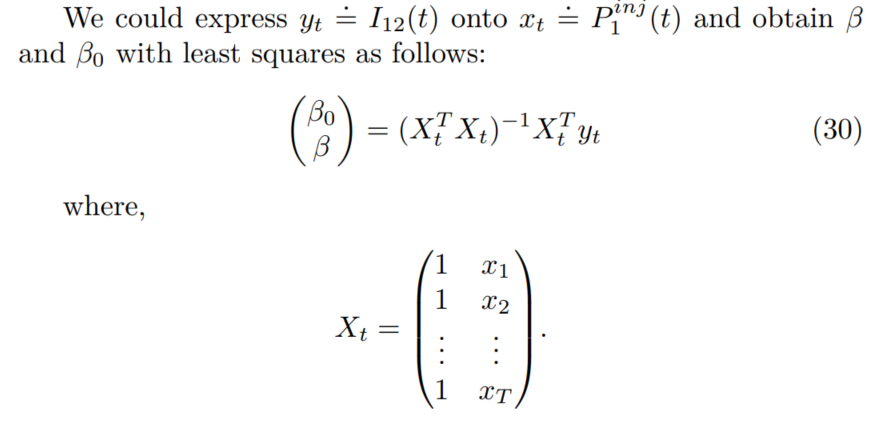

In [274]:
# Define the OLS regression relating the Current I12 with the Pinjection I1. See Equation (30) in the lecture notes
AA=np.ones((time,2))        #Vector Xt with ones
AA[:,1]=i1w[0:time]         #Vector Xt with ones in first column and wind injection in column 2 
AATransp=np.transpose(AA)
beta=np.dot(np.dot(np.linalg.inv(np.dot(AATransp,AA)),AATransp),i12[0:time])  # Beta values
print ("The value of Betas, using OLS, are:\n",beta)

The value of Betas, using OLS, are:
 [0.20178665 0.32969524]


<b>Plot initial data

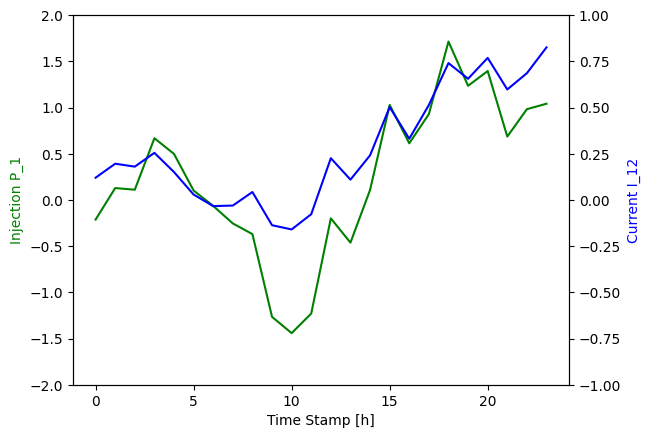

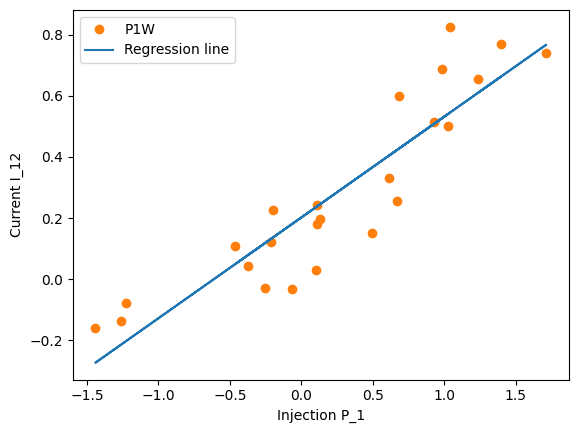

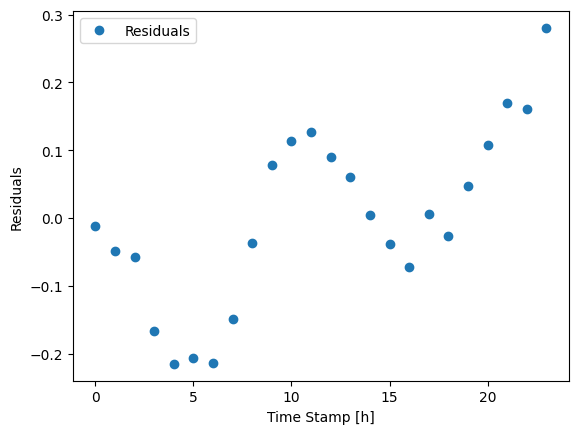

In [275]:

# Define the plots
x = range(time)
yy1 = i12[0:time]
yy2 = i1w[0:time]
rss_1=beta[0]+np.dot(beta[1],i1w[0:time])   #OLS regresion line
yy3 = rss_1
yy4 = i12[0:time]-beta[0]-np.dot(beta[1],i1w[0:time])

#First Graph (Pinjection in bus 1 and Current I12)
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(x, yy2, 'g-')
ax2.plot(x, yy1, 'b-')
ax1.set_xlabel('Time Stamp [h]')
ax1.set_ylabel('Injection P_1', color='g')
ax2.set_ylabel('Current I_12', color='b')
ax1.set_ylim([-2, 2])
ax2.set_ylim([-1, 1])
plt.xlabel("Time Stamp [h]")
plt.show()

#Second Graph (Relation I1 vs I12 and OLS regression)
plt.plot(yy2, yy1, 'C1o', label='P1W')
plt.plot(yy2, yy3, label='Regression line')
plt.legend()
plt.xlabel("Injection P_1")
plt.ylabel("Current I_12")
plt.show()

#Third Graph (Residuals - Difference between the real current I12 and the one obtained by OLS regression)
plt.plot(x, yy4, 'C0o', label='Residuals')
plt.legend()
plt.xlabel("Time Stamp [h]")
plt.ylabel("Residuals")
plt.show()


<b>Durbin-Watson statistic
    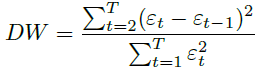

- The Durbin Watson statistic is a test for autocorrelation in a data set.
- The DW statistic always has a value between zero and 4.0.
- A value of 2.0 means there is no autocorrelation detected in the sample. Values from zero to 2.0 indicate positive autocorrelation and values from 2.0 to 4.0 indicate negative autocorrelation.

<sub>https://www.investopedia.com/terms/d/durbin-watson-statistic.asp

In [276]:
dw1 = np.sum((rss_1[1:time-1]-rss_1[0:time-2])**2)  # numerator 
dw2 = np.sum((rss_1[0:time-2])**2)                  # denominator
D = np.divide(dw1,dw2) 
ro = 1-D/2
print ("The value of Durdin-Watson (DW) is:",D)
print ("The value of rho is: ",ro)

The value of Durdin-Watson (DW) is: 0.19728601271078208
The value of rho is:  0.901356993644609


<b>Cochrane Orcutt
   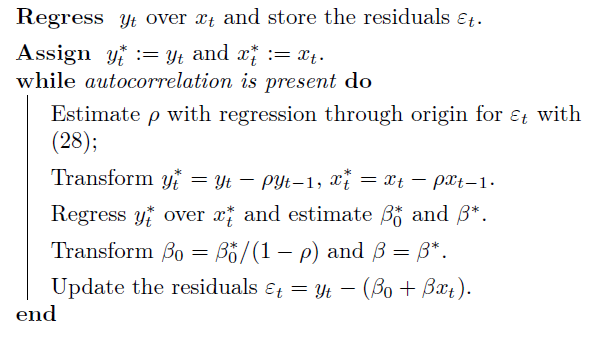

In [277]:
res_1=i12[0:time]-rss_1
for k in range(3):                   # According to "Applied Linear Statistical Models" if the OC methot does not converge 
                                     # in three iterations, we should use other method
    r2=res_1[0:time-1]
    r1=res_1[1:time]
    ro=0.97*np.dot(np.dot((np.dot(np.transpose(r2),r2))**(-1),np.transpose(r2)),r1) #Estimate Rho based on (28) 
    i1w_s=i1w[1:time]-np.dot(ro,i1w[0:time-1])   #Transform yt*=yt
    i12_s=i12[1:time]-np.dot(ro,i12[0:time-1])   #Transform xt*=Xt
    B=np.ones((time-1,2))
    B[:,1]=i1w_s
    b_s=np.dot(np.dot(np.linalg.inv(np.dot(np.transpose(B),B)),np.transpose(B)),np.transpose(i12_s)) #Regress yt* over xt*
    
    b_s[0]=np.divide(b_s[0],1-ro)               # Transform Beta_0
    rss_s=b_s[0]+np.dot(b_s[1],i1w_s[0:time-1]) # Update residuals
    rss_2=b_s[0]+np.dot(b_s[1],i1w[0:time])  
    res_2=i12[0:time]-rss_2
    res_1=res_2[:]                 
b_ss=b_s

<b>Forecast Day-ahead (Current I_12)

In [278]:
I12f1=beta[0]+np.dot(beta[1],i1w[time:time+timeForecast]) #using Ordinary least Squares (OLS)
I12f2=b_ss[0]+np.dot(b_ss[1],i1w[time:time+timeForecast]) #using Cochrane-Orcutt (CO)
print ("Forecast Corrent I12 considering OLS:",I12f1,"\n")
print ("Forecast Corrent I12 considering CO:",I12f2)

Forecast Corrent I12 considering OLS: [-0.03852579 -0.16027461 -0.23984907 -0.00887059  0.27985551  0.30672642
  0.45931817  0.40841983  0.37159782  0.40711795  0.22802822  0.7088563 ] 

Forecast Corrent I12 considering CO: [0.24980116 0.15115933 0.08668748 0.27382803 0.50775615 0.52952716
 0.65315818 0.61191995 0.58208647 0.61086516 0.46576528 0.8553359 ]


<b>Plot forecsated values

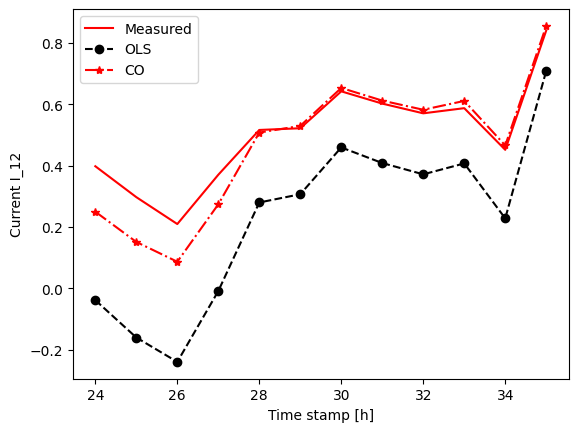

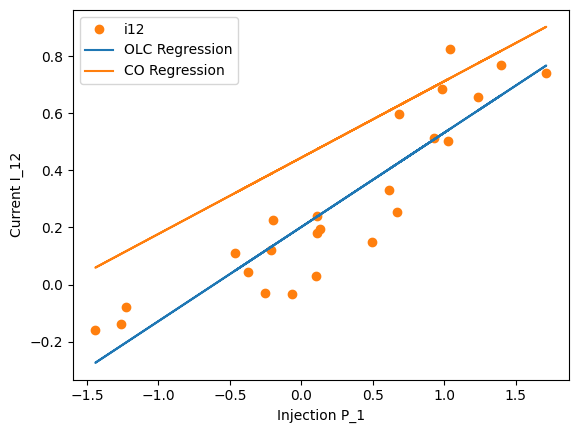

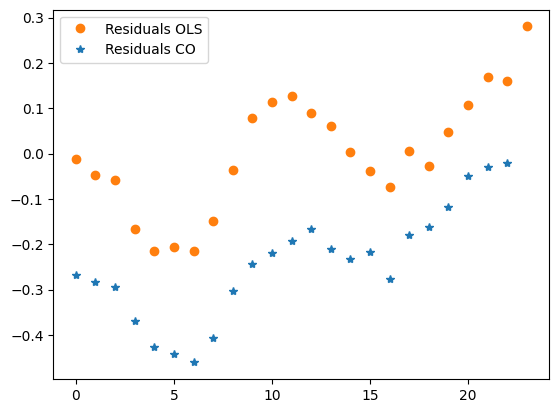

beta0 OLS: 0.2018
beta1 OLS: 0.3297
DW: 0.1973
rho: 0.9335


In [ ]:
x = range(time)
xx = range(time-1)
xxx = range(time,time+timeForecast)

yy1 = i12[0:time]
yy2 = i1w[0:time]
yy3 = rss_1
yy4 = rss_2
yy5 = i12[0:time]-rss_1
yy6 = i12[0:time-1]-rss_2[0:time-1]
yy7 = i12[time:time+timeForecast]
yy8 = I12f1
yy9 = I12f2

plt.plot(xxx, yy7,  color='red', label='Measured')
plt.plot(xxx, yy8, color='black', linestyle='dashed', marker='o', label='OLS')
plt.plot(xxx, yy9, color='red', linestyle='-.', marker='*', label='CO')
plt.legend()
plt.xlabel('Time stamp [h]')
plt.ylabel('Current I_12')
plt.show()

plt.plot(yy2, yy1, 'C1o', label='i12')
plt.plot(yy2, yy3, label='OLC Regression')
plt.plot(yy2, yy4, label='CO Regression')
plt.legend()
plt.xlabel("Injection P_1")
plt.ylabel("Current I_12")
plt.show()

plt.plot(x, yy5, 'C1o', label='Residuals OLS')
plt.plot(xx, yy6, 'C0*', label='Residuals CO')
plt.legend()
plt.show()

# No primeiro bloco (e/e1)
print(f"beta0 OLS: {beta[0]:.4f}")
print(f"beta1 OLS: {beta[1]:.4f}")
print(f"DW: {D:.4f}")
print(f"rho: {ro:.4f}")


<b>Autocorrelation Method 
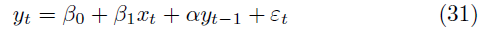
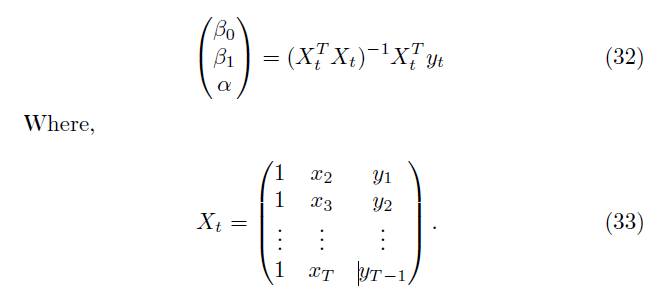

In this example, the input data is different because the error used to generate the values is different. To obtain the same results, we should use the next values. To compare with previous example, we can skip this step.

In [ ]:
# ANTES da regeneração com ee/ee1, guarda os dados de treino
i12_train = i12.copy()
i1w_train = i1w.copy()
II_train  = II.copy()

ee1 = [ 0.2878,   0.0145,   0.5846,  -0.0029,  -0.2718,  -0.1411,
       -0.2058,  -0.1793,  -0.9878,  -0.4926,  -0.1480,   0.7222,
       -0.3123,   0.4541,   0.9474,  -0.1584,   0.4692,   1.0173,
       -0.0503,   0.4684,  -0.3604,   0.4678,   0.3047,  -1.5098,
       -0.5515,  -0.5159,   0.3657,   0.7160,   0.1407,   0.5424,
        0.0409,   0.0450,   0.2365,  -0.3875,   1.4783,  -0.8487]

ee =  [ 0.2226,  -0.2293,  -0.1757,  -0.1691,  -0.2031,  -0.5900,
       -0.0556,  -0.0845,  -0.1834,   0.2798,   0.1534,   0.0751,
       -0.1089,   0.3545,   0.0228,  -0.2139,   0.4409,   0.6044,
       -0.2187,  -0.1233,   0.0026,   0.4980,   0.3703,   0.0812,
        0.1183,   0.2486,  -0.0686,  -0.0727,  -0.0009,  -0.1180,
        0.2443,   0.6224,  -0.4600,  -0.3878,   0.4734,  -0.4050]

II=np.zeros((nBus-1,time+timeForecast), dtype=complex)
II[:,0]=I
i12=np.zeros(time+timeForecast)
i1w=np.zeros(time+timeForecast)

v=1+np.dot(np.linalg.inv(Yl),I)
i12[0]=np.absolute(np.dot(Y[0,1],v[0]-v[1]))
i1w[0]=np.real(I[0])
for t in range(time+timeForecast-1):
    II[:,t+1]=0.95*II[:,t]+ee[t]
    i1w[t+1]=0.75*i1w[t]+ee1[t]
    # II[0,t+1]=i1w[t+1]+np.complex(0,np.imag(II[0,t+1]))
    II[0,t+1]=i1w[t+1]+complex(0,np.imag(II[0,t+1]))

    v=1+np.dot(np.linalg.inv(Yl),II[:,t+1])
    I12=np.dot(-Y[0,1],v[0]-v[1])
    i12[t+1]=np.absolute(I12)*np.sign(np.real(I12)) 



<b> Models
- 1 - OLS 
- 2 - Cochrane Orcutt (CO)
- 3 - Autorregration AR(1) 
- 4 - Autorregration with Loads AR(1)+Load Sum

Iteração 1: ro=0.7934 | beta0=0.1411 | beta1=0.1609 | MAE=0.3664
Iteração 2: ro=0.9475 | beta0=-0.0460 | beta1=0.1784 | MAE=0.1807
Iteração 3: ro=0.9593 | beta0=-0.1171 | beta1=0.1793 | MAE=0.1098
DW CO: 0.0383
beta0 CO: -0.1171
beta1 CO: 0.1793
ro final: 0.9593
I12f2: [-0.2478 -0.314  -0.3572 -0.2316 -0.0746 -0.06    0.023  -0.0047 -0.0247
 -0.0054 -0.1028  0.1587]
AR(1) betas: [0.0946 0.0636 0.505 ]
MAEEEEEEEEEEEEE AR(1): 0.20251869569137174
AR(1)+Load betas: [-0.0141  0.3354  0.0141 -0.0825]
DW AR(1)+Load: 1.7589
AR(1)+Load betas: [-0.0141  0.3354  0.0141 -0.0825]
I12f4: [-0.407  -0.5256 -0.6383 -0.4318 -0.1771 -0.1419  0.0151 -0.0739 -0.2466
 -0.0898 -0.1174  0.1399]
MAE AR(1)+Load: 0.0115
DW AR(1)+Load: 1.7589
AR(1)+Load betas: [-0.01414642  0.33535664  0.01406768 -0.08251639]
I12f4: [-0.407  -0.5256 -0.6383 -0.4318 -0.1771 -0.1419  0.0151 -0.0739 -0.2466
 -0.0898 -0.1174  0.1399]
MAE AR(1)+Load: 0.0115


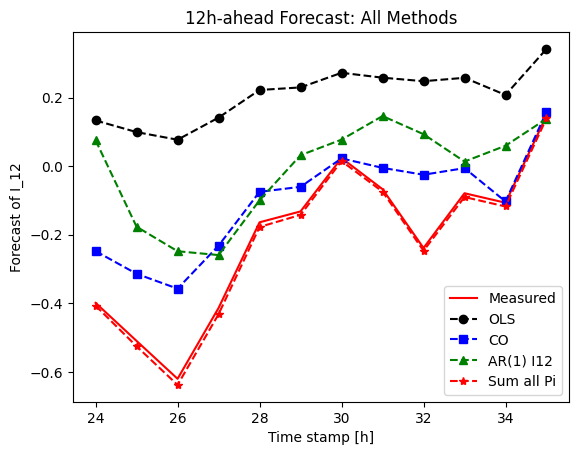

beta0 OLS: 0.2009
beta1 OLS: 0.0921
DW: 0.1973
rho: 0.9593
I12f1: [0.1337 0.0997 0.0775 0.142  0.2227 0.2302 0.2728 0.2586 0.2483 0.2582
 0.2082 0.3426]


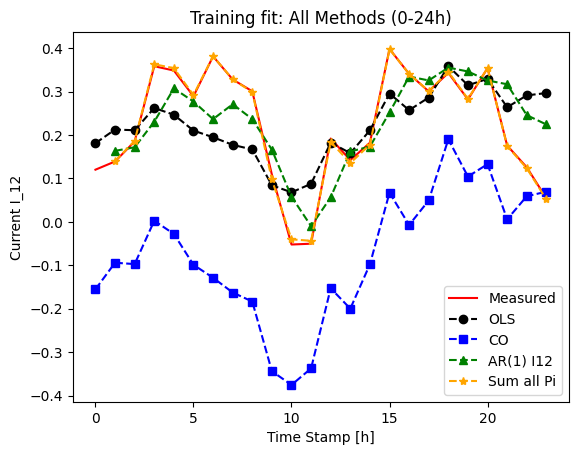

In [ ]:
#1 - OLS
X = np.ones((time, 2))
X[:,1] = i1w[0:time]
beta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), i12[0:time])
rss_1 = beta[0] + beta[1] * i1w[0:time]
I12f1 = beta[0] + beta[1] * i1w[time:time+timeForecast]


#2 - Cochrane Orcutt (CO)
res_1 = i12[0:time] - rss_1
ro_prev = 0

for k in range(3):
    r2 = res_1[0:time-1]
    r1 = res_1[1:time]
    ro = np.dot(r2, r1) / np.dot(r2, r2)
    
    i1w_s = i1w[1:time] - ro * i1w[0:time-1]
    i12_s = i12[1:time] - ro * i12[0:time-1]
    B = np.ones((time-1, 2))
    B[:,1] = i1w_s
    b_s = np.dot(np.dot(np.linalg.inv(np.dot(B.T, B)), B.T), i12_s)
    b_s[0] = b_s[0] / (1 - ro)
    rss_2 = b_s[0] + b_s[1] * i1w[0:time]
    res_1 = i12[0:time] - rss_2
    
    I12f2_iter = b_s[0] + b_s[1] * i1w[time:time+timeForecast]
    mae_iter = np.mean(np.abs(i12[time:time+timeForecast] - I12f2_iter))
    
    print(f"Iteração {k+1}: ro={ro:.4f} | beta0={b_s[0]:.4f} | beta1={b_s[1]:.4f} | MAE={mae_iter:.4f}")
    
    ro_prev = ro
I12f2 = b_s[0] + b_s[1] * i1w[time:time+timeForecast]

res_co = i12[0:time] - (b_s[0] + b_s[1]*i1w[0:time])
diff = res_co[1:] - res_co[:-1]
dw_co = np.sum(diff**2) / np.sum(res_co**2)


# 3 - AR(1) — usar sempre valores reais como lag
X_ar = np.ones((time-1, 3))
X_ar[:,1] = i1w[1:time]
X_ar[:,2] = i12[0:time-1]
beta_ar = np.linalg.inv(X_ar.T @ X_ar) @ X_ar.T @ i12[1:time]


I12f3 = np.zeros(timeForecast)

for k in range(timeForecast):
    I12f3[k] = (beta_ar[0]
                + beta_ar[1] * i1w[time+k]
                + beta_ar[2] * i12[time-1+k])   
    



# 4 - AR(1)+Load — usar sempre valores reais como lag
LoadSum = np.sum(np.real(II), axis=0)

X_arL = np.ones((time-1, 4))
X_arL[:,1] = i1w[1:time]
X_arL[:,2] = i12[0:time-1]
X_arL[:,3] = LoadSum[1:time]
beta_arL = np.linalg.inv(X_arL.T @ X_arL) @ X_arL.T @ i12[1:time]


I12f4 = np.zeros(timeForecast)

for k in range(timeForecast):
    I12f4[k] = (beta_arL[0]
                + beta_arL[1] * i1w[time+k]
                + beta_arL[2] * i12[time-1+k]     
                + beta_arL[3] * LoadSum[time+k])

fit_arL_train = np.zeros(time-1)
prev = i12[0]
for k in range(time-1):
    fit_arL_train[k] = (beta_arL[0] + beta_arL[1]*i1w[k+1] 
                        + beta_arL[2]*prev + beta_arL[3]*LoadSum[k+1])
    prev = i12[k+1]
res_arL = i12[1:time] - fit_arL_train
diff = res_arL[1:] - res_arL[:-1]
dw_arL = np.sum(diff**2) / np.sum(res_arL**2)
# print(f"DW AR(1)+Load: {dw_arL:.4f}")

# print(f"AR(1)+Load betas: {np.round(beta_arL, 4)}")
# print(f"I12f4: {np.round(I12f4, 4)}")
# print(f"MAE AR(1)+Load: {np.mean(np.abs(i12[time:time+timeForecast]-I12f4)):.4f}")
# print(f"DW AR(1)+Load: {dw_arL:.4f}")


# print(f"AR(1)+Load betas: {beta_arL}")
# print(f"I12f4: {np.round(I12f4, 4)}")
# print(f"MAE AR(1)+Load: {np.mean(np.abs(i12[time:time+timeForecast]-I12f4)):.4f}")




print(f"beta0 OLS: {beta[0]:.4f}")
print(f"beta1 OLS: {beta[1]:.4f}")
print(f"DW: {D:.4f}")
print(f"rho: {ro:.4f}")
print(f"I12f1: {np.round(I12f1, 4)}")

# Gráfico de treino 
x = range(time)

fit_ols = beta[0] + beta[1] * i1w[0:time]
fit_co  = b_s[0] + b_s[1] * i1w[0:time]

fit_ar = np.zeros(time-1)
prev_I12 = i12[0]
for k in range(time-1):
    fit_ar[k] = beta_ar[0] + beta_ar[1]*i1w[k+1] + beta_ar[2]*prev_I12
    prev_I12 = i12[k+1]  

fit_arL = np.zeros(time-1)
prev_I12 = i12[0]
for k in range(time-1):
    fit_arL[k] = (beta_arL[0] + beta_arL[1]*i1w[k+1]
                  + beta_arL[2]*prev_I12 + beta_arL[3]*LoadSum[k+1])
    prev_I12 = i12[k+1]  




<b>Forecast Day-ahead (Current I_12)

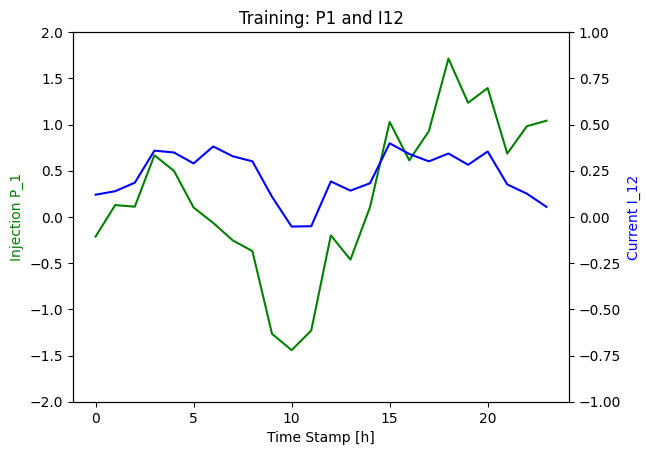

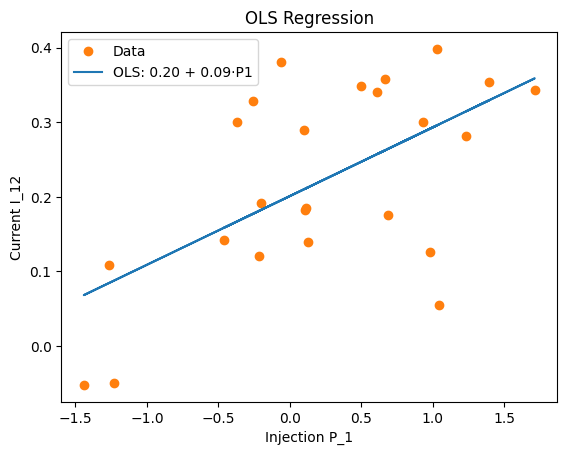

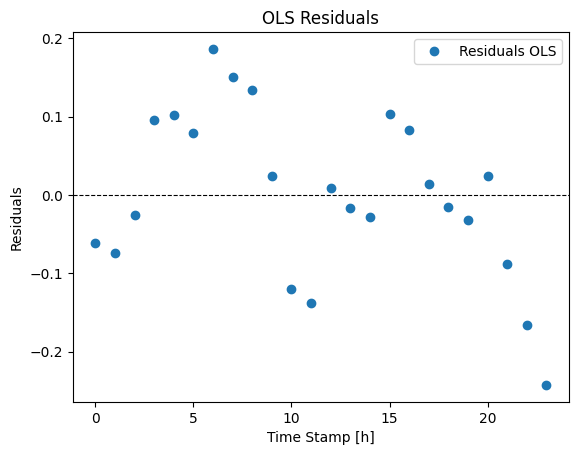

MAE OLS:        0.4210
MAE CO:         0.1098
MAE AR(1):      0.2025
MAE AR(1)+Load: 0.0115
DW OLS:         0.1973
DW CO:          0.0383
DW AR(1):       1.2045
DW AR(1)+Load:  1.7589


In [ ]:




# MAE de todos os métodos
print(f"MAE OLS:        {np.mean(np.abs(i12[time:time+timeForecast]-I12f1)):.4f}")
print(f"MAE CO:         {np.mean(np.abs(i12[time:time+timeForecast]-I12f2)):.4f}")
print(f"MAE AR(1):      {np.mean(np.abs(i12[time:time+timeForecast]-I12f3)):.4f}")
print(f"MAE AR(1)+Load: {np.mean(np.abs(i12[time:time+timeForecast]-I12f4)):.4f}")

# DW de todos os métodos
print(f"DW OLS:         {D:.4f}")
print(f"DW CO:          0.0383")
print(f"DW AR(1):       1.2045")
print(f"DW AR(1)+Load:  1.7589")

<b>Plot forecsated values

In [ ]:
plt.figure()
plt.plot(x, i12[0:time], color='red', label='Measured')
plt.plot(x, fit_ols, color='black', linestyle='dashed', marker='o', label='OLS')
plt.plot(x, fit_co, color='blue', linestyle='dashed', marker='s', label='CO')
plt.plot(range(1, time), fit_ar, color='green', linestyle='dashed', marker='^', label='AR(1) I12')
plt.plot(range(1, time), fit_arL, color='orange', linestyle='dashed', marker='*', label='Sum all Pi')
plt.legend()
plt.xlabel('Time Stamp [h]')
plt.ylabel('Current I_12')
plt.title('Training fit: All Methods (0-24h)')
plt.show()

# Gráfico final
xxx = range(time, time+timeForecast)
plt.plot(xxx, i12[time:time+timeForecast], color='red', label='Measured')
plt.plot(xxx, I12f1, color='black', linestyle='dashed', marker='o', label='OLS')
plt.plot(xxx, I12f2, color='blue', linestyle='dashed', marker='s', label='CO')
plt.plot(xxx, I12f3, color='green', linestyle='dashed', marker='^', label='AR(1) I12')
plt.plot(xxx, I12f4, color='red', linestyle='dashed', marker='*', label='Sum all Pi')
plt.legend()
plt.xlabel('Time stamp [h]')
plt.ylabel('Forecast of I_12')
plt.title('12h-ahead Forecast: All Methods')
plt.show()

<b>Durbin-Watson statistic

# Homework Project Goals
Think about an interesting variation to this problem or a different way to solve and implement it !!!

Some ideas:
- Use <i>P<sub>2</sub></i> from the example to define the same stationary process for all grid loads, i.e., make <i>t : Pt = P2 </i>and use the data on <i>x<sub>t</sub>, t = 1, . . . , 12</i> from Fig. 27 as wind power output, <i>W<sub>t</sub></i>. Compute the current <i>I<sub>12</sub></i> with <i>Y<sup>−1</sup></i> and regress it (with AR(1)) over loads’ first 12-periods data to predict the following 12-periods. Analyse the residuals’ autocorrelation.
- Use the Cochrane–Orcutt transformation to correct for the autocorrelation of the residuals and re-run the prediction.
Did the transformation improve the prediction? Why?
- In the example, Explore other methods to correct for the autocorrelation of the residuals and re-run the prediction (suggestion: see M. H. Kutner, C. Nachtsheim, J. Neter, and W. Li, Applied linear
statistical models. Boston: McGraw-Hill Irwin, 2005.) Did the transformation improve the prediction of the current? Why?

EXTRA 1

P2: [0.064 0.164 0.708 3.44  2.176 3.02  0.916 0.64  0.684 0.564 0.356 0.22
 0.528]
P2 shape: (13,)
Wind power Wt (0-12h): [-0.2128      0.1282      0.11065     0.6675875   0.49779063  0.10154297
 -0.06494277 -0.25450708 -0.37018031 -1.26543523 -1.44167642 -1.22925732]

I12 extra:
[-0.0374  0.0729  0.2039  1.0233  0.6662  0.7771  0.2118  0.0957  0.0778
 -0.1768 -0.2726 -0.2532  0.0782  0.048   0.0685  0.3433  0.9808  0.567
  0.7354  0.1644  0.0669 -0.1471 -0.2209 -0.2194]

AR(1) extra betas:
beta0 = 0.2984
beta1 = 0.4416
alpha = 0.1975

Forecast AR(1) extra:
[ 0.305   0.3627  0.6027  0.5317  0.411   0.4634  0.298   0.2801 -0.228
 -0.3251 -0.2735  0.1608]

DW AR(1) extra: 2.1696
rho extra:      -0.0848


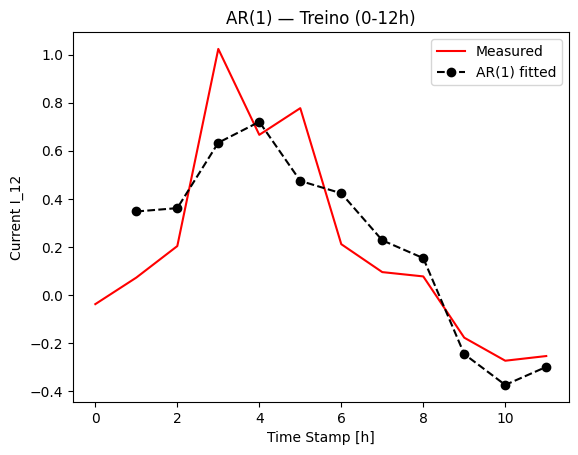

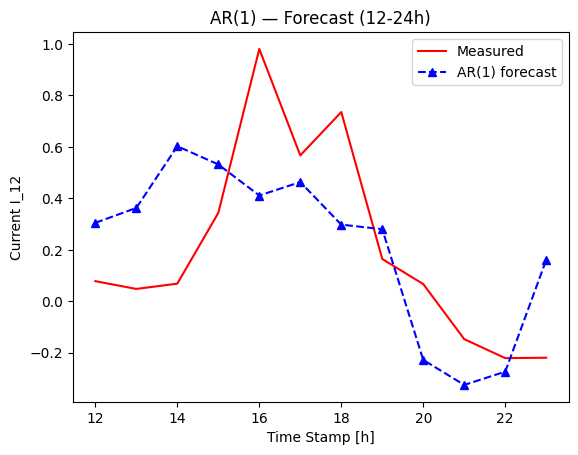

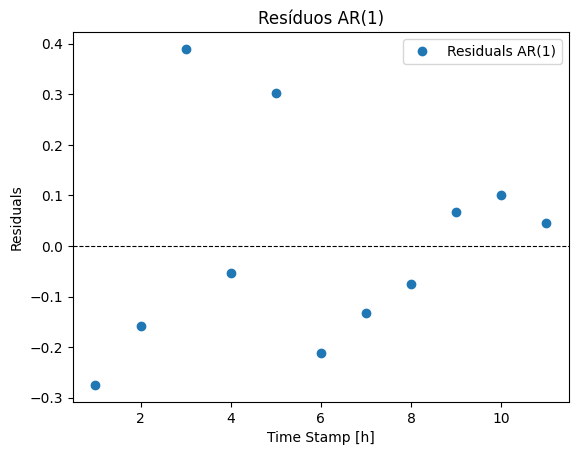

In [ ]:
# =============================================================================
# EXTRA — AR(1) com P2 como processo estacionário para todas as cargas
# =============================================================================

P2 = Power_Info[:, 1]  
# print(f"P2: {P2}")
# print(f"P2 shape: {P2.shape}")

timeExtra         = 12 
timeForecastExtra = 12 

Wt = i1w[0:timeExtra]
# print(f"Wind power Wt (0-12h): {Wt}")

i12_extra = np.zeros(timeExtra + timeForecastExtra)

for t in range(timeExtra + timeForecastExtra):

    P_wind = Wt[t % timeExtra]

    p2_val = P2[t % len(P2)]
    P_loads = -p2_val * np.ones(3)

    P_inj     = np.array([P_wind, P_loads[0], P_loads[1], P_loads[2]])
    P_complex = P_inj * np.exp(complex(0, 1) * np.arccos(cosPhi))
    I_extra   = np.conj(P_complex)

    v_extra   = 1 + np.dot(np.linalg.inv(Yl), I_extra)
    I12_extra = np.dot(-Y[0, 1], v_extra[0] - v_extra[1])
    i12_extra[t] = np.abs(I12_extra) * np.sign(np.real(I12_extra))

# print(f"\nI12 extra:\n{np.round(i12_extra, 4)}")



y_extra = i12_extra[1:timeExtra]           
X_extra = np.ones((timeExtra-1, 3))
X_extra[:, 1] = Wt[1:timeExtra]            
X_extra[:, 2] = i12_extra[0:timeExtra-1]   

beta_extra, _, _, _ = np.linalg.lstsq(X_extra, y_extra, rcond=None)

# print(f"\nAR(1) extra betas:")
# print(f"beta0 = {beta_extra[0]:.4f}")
# print(f"beta1 = {beta_extra[1]:.4f}")
# print(f"alpha = {beta_extra[2]:.4f}")


I12f_extra = np.zeros(timeForecastExtra)

for k in range(timeForecastExtra):
    I12f_extra[k] = (beta_extra[0]
                     + beta_extra[1] * Wt[(1 + k) % timeExtra]
                     + beta_extra[2] * i12_extra[k + timeExtra - 1])  

# print(f"\nForecast AR(1) extra:\n{np.round(I12f_extra, 4)}")



fitted_extra = (beta_extra[0]
                + beta_extra[1] * Wt[1:timeExtra]
                + beta_extra[2] * i12_extra[0:timeExtra-1])

res_extra = i12_extra[1:timeExtra] - fitted_extra

diff_extra = res_extra[1:] - res_extra[:-1]
dw_extra   = np.sum(diff_extra**2) / np.sum(res_extra**2)
rho_extra  = 1 - dw_extra/2

# print(f"\nDW AR(1) extra: {dw_extra:.4f}")
# print(f"rho extra:      {rho_extra:.4f}")



# # Gráfico 1 — Treino (0-12h)
# plt.figure()
# plt.plot(range(timeExtra), i12_extra[0:timeExtra],
#          color='red', label='Measured')
# plt.plot(range(1, timeExtra), fitted_extra,
#          color='black', linestyle='dashed', marker='o', label='AR(1) fitted')
# plt.legend()
# plt.xlabel('Time Stamp [h]')
# plt.ylabel('Current I_12')
# plt.title('AR(1) — Treino (0-12h)')
# plt.show()

# # Gráfico 2 — Forecast (12-24h)
# plt.figure()
# plt.plot(range(timeExtra, timeExtra + timeForecastExtra),
#          i12_extra[timeExtra:timeExtra + timeForecastExtra],
#          color='red', label='Measured')
# plt.plot(range(timeExtra, timeExtra + timeForecastExtra),
#          I12f_extra,
#          color='blue', linestyle='dashed', marker='^', label='AR(1) forecast')
# plt.legend()
# plt.xlabel('Time Stamp [h]')
# plt.ylabel('Current I_12')
# plt.title('AR(1) — Forecast (12-24h)')
# plt.show()

# # Gráfico 3 — Resíduos
# plt.figure()
# plt.plot(range(1, timeExtra), res_extra, 'C0o', label='Residuals AR(1)')
# plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
# plt.legend()
# plt.xlabel('Time Stamp [h]')
# plt.ylabel('Residuals')
# plt.title('Resíduos AR(1)')
# plt.show()


EXTRA 2

Resíduos AR(1) Extra 1:
[-0.2747 -0.1577  0.3898 -0.0541  0.3023 -0.2114 -0.1321 -0.076   0.0682
  0.1006  0.0451]
DW AR(1) Extra 1: 2.1696
rho AR(1) Extra 1: -0.0848

rho estimado CO Extra 2: -0.1754

CO Extra 2 betas:
beta0 = 0.3464
beta1 = 0.4793
alpha = 0.1466

DW CO Extra 2: 2.5723
rho CO Extra 2: -0.2861

Forecast CO Extra 2:
[ 0.2072  0.4382  0.4637  0.7344  0.6927  0.4966  0.3881  0.2813  0.2102
 -0.2294 -0.3783 -0.2983]

MAE AR(1) Extra 1: 0.2830
MAE CO Extra 2:    0.2158


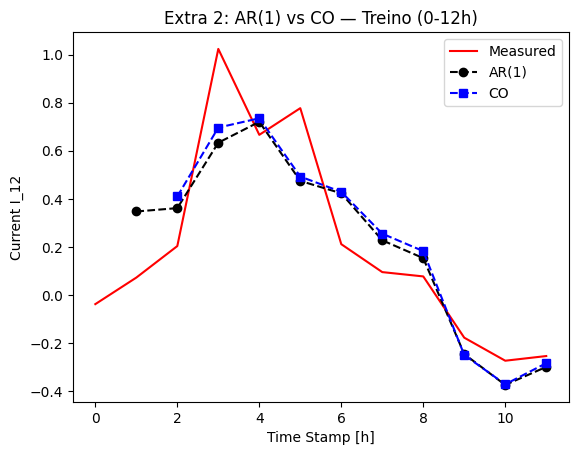

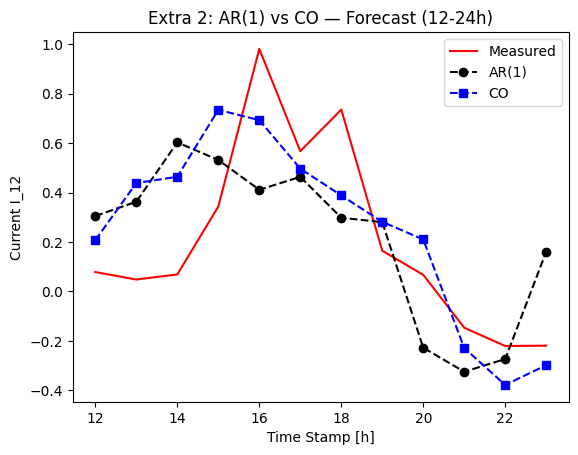

In [ ]:
# =============================================================================
# EXTRA 2 — Cochrane-Orcutt aplicado ao AR(1) do Extra 1
# =============================================================================

res_extra1 = i12_extra[1:timeExtra] - fitted_extra

# print(f"Resíduos AR(1) Extra 1:\n{np.round(res_extra1, 4)}")
# print(f"DW AR(1) Extra 1: {dw_extra:.4f}")
# print(f"rho AR(1) Extra 1: {rho_extra:.4f}")

r2_ex = res_extra1[0:-1]
r1_ex = res_extra1[1:]
ro_extra = np.dot(r2_ex, r1_ex) / np.dot(r2_ex, r2_ex)
# print(f"\nrho estimado CO Extra 2: {ro_extra:.4f}")

# Transformar variáveis
# y* = I12(t) - rho*I12(t-1)
# x1* = Wt - rho*Wt-1
# x2* = I12(t-1) - rho*I12(t-2)
# precisamos de t=2,...,11 (9 pontos)
i12_s_ex  = i12_extra[2:timeExtra]   - ro_extra * i12_extra[1:timeExtra-1]
Wt_s_ex   = Wt[2:timeExtra]          - ro_extra * Wt[1:timeExtra-1]
I12lag_s  = i12_extra[1:timeExtra-1] - ro_extra * i12_extra[0:timeExtra-2]

X_co_ex = np.ones((timeExtra-2, 3))
X_co_ex[:, 1] = Wt_s_ex
X_co_ex[:, 2] = I12lag_s

beta_co_ex, _, _, _ = np.linalg.lstsq(X_co_ex, i12_s_ex, rcond=None)
beta_co_ex[0] = beta_co_ex[0] / (1 - ro_extra)  

# print(f"\nCO Extra 2 betas:")
# print(f"beta0 = {beta_co_ex[0]:.4f}")
# print(f"beta1 = {beta_co_ex[1]:.4f}")
# print(f"alpha = {beta_co_ex[2]:.4f}")

fitted_co_ex = np.zeros(timeExtra-2)
for k in range(timeExtra-2):
    fitted_co_ex[k] = (beta_co_ex[0] 
                       + beta_co_ex[1] * Wt[k+2] 
                       + beta_co_ex[2] * i12_extra[k+1])

res_co_ex  = i12_extra[2:timeExtra] - fitted_co_ex
diff_co_ex = res_co_ex[1:] - res_co_ex[:-1]
dw_co_ex   = np.sum(diff_co_ex**2) / np.sum(res_co_ex**2)
rho_co_ex  = 1 - dw_co_ex/2

# print(f"\nDW CO Extra 2: {dw_co_ex:.4f}")
# print(f"rho CO Extra 2: {rho_co_ex:.4f}")

I12f_co_ex = np.zeros(timeForecastExtra)
prev_I12   = i12_extra[timeExtra-1]

for k in range(timeForecastExtra):
    I12f_co_ex[k] = (beta_co_ex[0]
                     + beta_co_ex[1] * Wt[k % timeExtra]
                     + beta_co_ex[2] * prev_I12)
    prev_I12 = I12f_co_ex[k]

# print(f"\nForecast CO Extra 2:\n{np.round(I12f_co_ex, 4)}")

# MAE
mae_ar1_ex = np.mean(np.abs(i12_extra[timeExtra:] - I12f_extra))
mae_co_ex  = np.mean(np.abs(i12_extra[timeExtra:] - I12f_co_ex))
# print(f"\nMAE AR(1) Extra 1: {mae_ar1_ex:.4f}")
# print(f"MAE CO Extra 2:    {mae_co_ex:.4f}")



EXTRA 3

PRAIS-WINSTEN


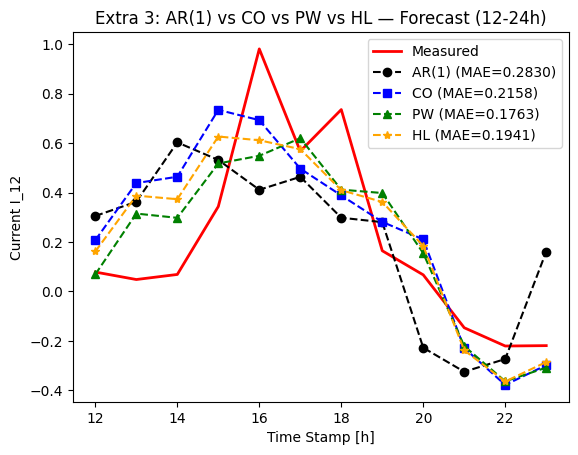

In [ ]:
res_ar1_ex = i12_extra[1:timeExtra] - fitted_extra

# =========================================================
# METODO 1 — PRAIS-WINSTEN (PW)
# =========================================================
# print("=" * 50)
# print("PRAIS-WINSTEN")
# print("=" * 50)

res_pw_ex = res_ar1_ex.copy()

for k in range(3):
    r2_pw = res_pw_ex[:-1]
    r1_pw = res_pw_ex[1:]
    ro_pw = np.dot(r2_pw, r1_pw) / np.dot(r2_pw, r2_pw)

    y1_pw = np.sqrt(1 - ro_pw**2) * i12_extra[1]
    x1_pw = np.sqrt(1 - ro_pw**2) * Wt[1]
    z1_pw = np.sqrt(1 - ro_pw**2) * i12_extra[0]

    yt_pw = i12_extra[2:timeExtra]   - ro_pw * i12_extra[1:timeExtra-1]
    xt_pw = Wt[2:timeExtra]          - ro_pw * Wt[1:timeExtra-1]
    zt_pw = i12_extra[1:timeExtra-1] - ro_pw * i12_extra[0:timeExtra-2]

    y_pw_full = np.concatenate([[y1_pw], yt_pw])
    x_pw_full = np.concatenate([[x1_pw], xt_pw])
    z_pw_full = np.concatenate([[z1_pw], zt_pw])

    B_pw = np.ones((timeExtra-1, 3))
    B_pw[:, 1] = x_pw_full
    B_pw[:, 2] = z_pw_full

    b_pw, _, _, _ = np.linalg.lstsq(B_pw, y_pw_full, rcond=None)
    b_pw[0] = b_pw[0] / (1 - ro_pw)

    fitted_pw_train = (b_pw[0] + b_pw[1]*Wt[1:timeExtra] 
                       + b_pw[2]*i12_extra[0:timeExtra-1])
    res_pw_ex = i12_extra[1:timeExtra] - fitted_pw_train

    # print(f"Iteração {k+1}: ro={ro_pw:.4f} | beta0={b_pw[0]:.4f} | beta1={b_pw[1]:.4f} | alpha={b_pw[2]:.4f}")

diff_pw_ex = res_pw_ex[1:] - res_pw_ex[:-1]
dw_pw_ex   = np.sum(diff_pw_ex**2) / np.sum(res_pw_ex**2)
# print(f"DW PW: {dw_pw_ex:.4f}  |  rho: {1-dw_pw_ex/2:.4f}")

I12f_pw_ex = np.zeros(timeForecastExtra)
for k in range(timeForecastExtra):
    I12f_pw_ex[k] = (b_pw[0]
                     + b_pw[1] * Wt[(timeExtra + k) % timeExtra]
                     + b_pw[2] * i12_extra[timeExtra - 1 + k])   # <-- REAL

mae_pw_ex = np.mean(np.abs(i12_extra[timeExtra:] - I12f_pw_ex))
# print(f"MAE PW: {mae_pw_ex:.4f}")

# =========================================================
# MÉTODO 2 — HILDRETH-LU (HL)
# =========================================================
# print("\n" + "=" * 50)
# print("HILDRETH-LU")
# print("=" * 50)

rho_grid = np.arange(-0.99, 0.99, 0.01)
sse_grid = np.zeros(len(rho_grid))

for idx, rho_test in enumerate(rho_grid):
    yt_hl = i12_extra[2:timeExtra]   - rho_test * i12_extra[1:timeExtra-1]
    xt_hl = Wt[2:timeExtra]          - rho_test * Wt[1:timeExtra-1]
    zt_hl = i12_extra[1:timeExtra-1] - rho_test * i12_extra[0:timeExtra-2]

    B_hl = np.ones((timeExtra-2, 3))
    B_hl[:, 1] = xt_hl
    B_hl[:, 2] = zt_hl

    b_hl, _, _, _ = np.linalg.lstsq(B_hl, yt_hl, rcond=None)
    b_hl[0] = b_hl[0] / (1 - rho_test)

    fitted_hl = (b_hl[0] + b_hl[1]*Wt[1:timeExtra] 
                 + b_hl[2]*i12_extra[0:timeExtra-1])
    res_hl    = i12_extra[1:timeExtra] - fitted_hl
    sse_grid[idx] = np.sum(res_hl**2)

best_idx = np.argmin(sse_grid)
ro_hl    = rho_grid[best_idx]
# print(f"Rho ótimo HL: {ro_hl:.4f}")

yt_hl_best = i12_extra[2:timeExtra]   - ro_hl * i12_extra[1:timeExtra-1]
xt_hl_best = Wt[2:timeExtra]          - ro_hl * Wt[1:timeExtra-1]
zt_hl_best = i12_extra[1:timeExtra-1] - ro_hl * i12_extra[0:timeExtra-2]

B_hl_best = np.ones((timeExtra-2, 3))
B_hl_best[:, 1] = xt_hl_best
B_hl_best[:, 2] = zt_hl_best

b_hl_best, _, _, _ = np.linalg.lstsq(B_hl_best, yt_hl_best, rcond=None)
b_hl_best[0] = b_hl_best[0] / (1 - ro_hl)

# print(f"beta0 HL: {b_hl_best[0]:.4f}")
# print(f"beta1 HL: {b_hl_best[1]:.4f}")
# print(f"alpha HL: {b_hl_best[2]:.4f}")

# DW HL
fitted_hl_best = (b_hl_best[0] + b_hl_best[1]*Wt[1:timeExtra] 
                  + b_hl_best[2]*i12_extra[0:timeExtra-1])
res_hl_best    = i12_extra[1:timeExtra] - fitted_hl_best
diff_hl        = res_hl_best[1:] - res_hl_best[:-1]
dw_hl          = np.sum(diff_hl**2) / np.sum(res_hl_best**2)
# print(f"DW HL: {dw_hl:.4f}  |  rho: {1-dw_hl/2:.4f}")

I12f_hl_ex = np.zeros(timeForecastExtra)
for k in range(timeForecastExtra):
    I12f_hl_ex[k] = (b_hl_best[0]
                     + b_hl_best[1] * Wt[(timeExtra + k) % timeExtra]
                     + b_hl_best[2] * i12_extra[timeExtra - 1 + k])   # <-- REAL

mae_hl_ex = np.mean(np.abs(i12_extra[timeExtra:] - I12f_hl_ex))
# print(f"MAE HL: {mae_hl_ex:.4f}")


x_fore = range(timeExtra, timeExtra + timeForecastExtra)

plt.figure()
plt.plot(x_fore, i12_extra[timeExtra:], color='red', linewidth=2, label='Measured')
plt.plot(x_fore, I12f_extra, color='black', linestyle='dashed', marker='o', label=f'AR(1) (MAE={mae_ar1_ex:.4f})')
plt.plot(x_fore, I12f_co_ex, color='blue', linestyle='dashed', marker='s', label=f'CO (MAE={mae_co_ex:.4f})')
plt.plot(x_fore, I12f_pw_ex, color='green', linestyle='dashed', marker='^', label=f'PW (MAE={mae_pw_ex:.4f})')
plt.plot(x_fore, I12f_hl_ex, color='orange', linestyle='dashed', marker='*', label=f'HL (MAE={mae_hl_ex:.4f})')
plt.legend()
plt.xlabel('Time Stamp [h]')
plt.ylabel('Current I_12')
plt.title('Extra 3: AR(1) vs CO vs PW vs HL — Forecast (12-24h)')
plt.show()


# print("\n" + "="*50)
# print("VALORES DE DURBIN–WATSON (DW) — EXTRAS")
# print("="*50)

# print(f"AR(1) Extra 1:        DW = {dw_extra:.4f}")
# print(f"Cochrane–Orcutt:      DW = {dw_co_ex:.4f}")
# print(f"Prais–Winsten:        DW = {dw_pw_ex:.4f}")
# print(f"Hildreth–Lu:          DW = {dw_hl:.4f}")
# print("="*50)


# print("\n" + "="*60)
# print("COEFICIENTES ESTIMADOS — EXTRA 3")
# print("="*60)

# print("Prais–Winsten (PW):")
# print(f"  beta0 = {b_pw[0]:.6f}")
# print(f"  beta1 = {b_pw[1]:.6f}")
# print(f"  alpha = {b_pw[2]:.6f}")

# print("\nHildreth–Lu (HL):")
# print(f"  beta0 = {b_hl_best[0]:.6f}")
# print(f"  beta1 = {b_hl_best[1]:.6f}")
# print(f"  alpha = {b_hl_best[2]:.6f}")

# print("="*60)



# print("\n" + "="*60)
# print("MAE — MÉTODOS EXTRA 1, 2 e 3")
# print("="*60)

# print(f"AR(1) Extra 1:          MAE = {mae_ar1_ex:.6f}")
# print(f"Cochrane–Orcutt:        MAE = {mae_co_ex:.6f}")
# print(f"Prais–Winsten:          MAE = {mae_pw_ex:.6f}")
# print(f"Hildreth–Lu:            MAE = {mae_hl_ex:.6f}")

# print("="*60)
